# LAB | Post-project review — stakeholders & real-world scope

### Name of the project: Amplify: give written content a voice

## Part 1: Project snapshot

This project addresses the challenge of making dense written content more accessible and engaging by automatically converting PDF documents into audio podcast episodes. The intended users are the four hosts themselves — Ankita, Oli, Alex, and Dilia — who wanted a tool that could transform reading material into a conversational format they could listen to and share as a stream. The delivered MVP accepts a PDF upload, uses GPT-4o to rewrite the content as a multi-host dialogue, generates individual audio segments for each host using OpenAI TTS voices, stitches them into a single MP3, and optionally transcribes the result via Whisper — all through a simple Gradio web interface. 


## Part 2: Stakeholder impact

Review table: ![Stakeholder impact.png](<attachment:Stakeholder impact.png>)
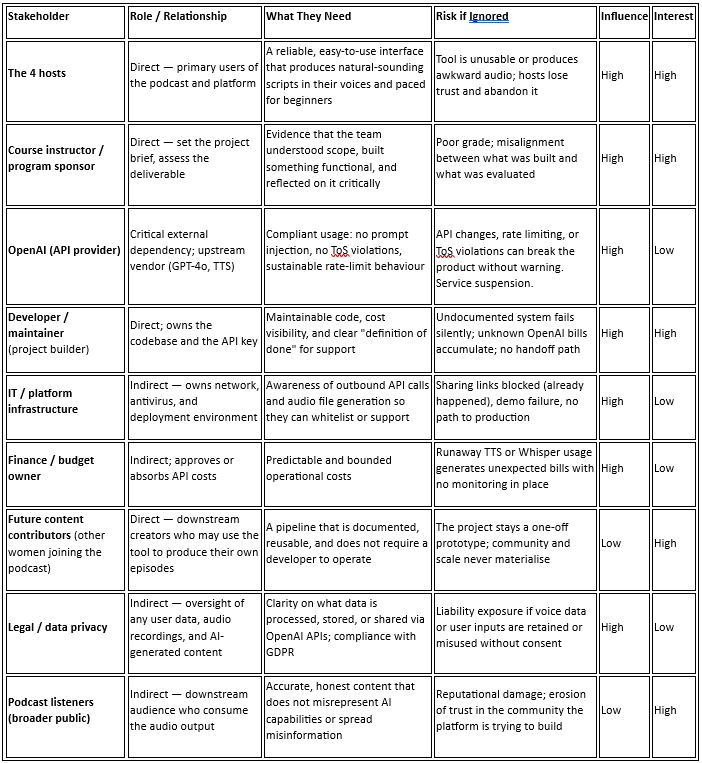

## Part 3: From demo to “real project”

### Operations
The demo has no monitoring, no alerting, and no defined owner for when something breaks: if the pipeline fails, no one finds out until someone tries to use it. 
In production, each pipeline step would need structured logging and alerting on error rate spikes or generation time thresholds. On-call ownership would need to be explicit: who gets notified, what the response time expectation is, and what qualifies as an incident. There is also no backup strategy for generated outputs, a production system would need a deliberate decision on whether and where to persist them, even if the answer is "briefly and then delete."
DN:  an uptime monitor for the Gradio endpoint, and a defined owner for incidents — for example, if the TTS API goes down mid-episode, who restarts the job and how? 

### Security & compliance 
The demo has no real access control: the OpenAI API key is almost certainly stored in plain text, the Gradio link is public to anyone who has it, and no one has reviewed what OpenAI does with submitted text under its data retention policies. In production, credentials would move to a secrets manager, the interface would sit behind authentication, and a data processing agreement with OpenAI would need to be in place before any user input flows through the API, especially under GDPR.

### Data lifecycle 
Audio files accumulate with no defined policy (the audio_segments/ bug already illustrates this). 
The demo accepts any PDF without checking what it contains or who owns it. In a real deployment you would need a clear policy: are hosts only allowed to process their own original content? Public-domain texts? Licensed material? 
 Is also needed to decide whether uploaded PDFs and generated audio are retained on disk after the episode is produced, and for how long, especially if the hosting environment is shared. 

### Handoff & documentation 
Today, the developer is the only person who can diagnose failures or update the code. For a real handoff to the hosts, you would need a written runbook (what to do if a PDF fails to parse, what to do if audio segments are silent), a guide for rotating the API key, and a clear definition of what "support" means after the initial build — whether the developer is on call or the hosts are self-sufficient. 

### Accessibility 
The current output is audio with a raw transcript below, no speaker labels in the UI, and no screen reader testing. This matters particularly for this product because the target audience includes women studying or working around other commitments, situations where listening is not always possible. 
In production the transcript would be a first-class output: formatted with speaker names, timestamped, downloadable as a standalone document, not an afterthought below the audio player.


## Part 4: Revision brief

### Before:
The goal of this project was to build a fun, working tool for four friends who podcast together, take a PDF, push a button, get an MP3 in four distinct voices. Success meant the audio played, the hosts sounded roughly like their assigned personalities, and the whole thing ran on one laptop without too much setup. 
The scope was intentionally a demo: if it worked in a live walkthrough, it was done.

### After: 
We would reframe success to include three additional criteria beyond "the audio plays": the tool runs reliably without the developer present (documented runbook, error recovery, no hardcoded secrets), the cost per episode is visible and bounded before each run (a pre-flight token estimate and a monthly spend cap), and the hosts have been walked through at least one failure scenario so they can self-recover. We would narrow the MVP to exclude Whisper transcription  as it adds cost and latency and the hosts did not identify it as a core need, and instead add a one-page operator guide as a required deliverable before calling the project done. A content-rights check (is this PDF something we're allowed to broadcast?) would also be added as a gate before audio generation begins.
